# Synthetic Ground-Truth Training

Validation experiment: generate a voltage trace from **known** AdEx parameters,
then attempt to recover those parameters via gradient-based training.

This isolates the training pipeline from experimental noise — if training works here,
any failure on real data points to data/model mismatch rather than pipeline bugs.

**Setup:**
- Ground truth parameters: Naud "adaptation" set (configurable)
- Current stimulus: reuses experimental current waveform for realism
- Initial parameters: small perturbation (~15%) from ground truth
- Two-stage training: Stage 1 (Guarino, coarse) → Stage 2 (fine-tune adaptation)

In [1]:
import logging

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatures,
    GuarinoLossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    guarino_loss,
    make_guarino_loss_fn,
    make_van_rossum_loss_fn,
    spike_train_from_voltage,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 42

## 1. Ground Truth Parameters & Current Stimulus

Build a synthetic step-current stimulus (independent of experimental sampling),
then define ground truth AdEx parameters. Using a synthetic current lets us
freely adjust `dt_ms` and the stim window without being tied to a recording.

In [2]:
# --- Synthetic step-current waveform ---
# Adjust dt_ms / t_max_ms / stim window freely; no experimental data dependency.
dt_ms = 0.025
t_max_ms = 100.0
stim_delay_ms = 5.0
stim_duration_ms = 95.0
stim_current_pA = 415.0

n_samples = int(round(t_max_ms / dt_ms))
time_arr = np.arange(n_samples) * dt_ms
current_arr = np.zeros(n_samples)
stim_start_idx = int(round(stim_delay_ms / dt_ms))
stim_end_idx = int(round((stim_delay_ms + stim_duration_ms) / dt_ms))
current_arr[stim_start_idx:stim_end_idx] = stim_current_pA

exp_cropped = TraceData(
    time=time_arr,
    voltage=np.zeros(n_samples),  # placeholder; GT voltage is simulated below
    current=current_arr,
    dt_ms=dt_ms,
    spike_times=np.array([]),
    stim_start_idx=stim_start_idx,
    stim_end_idx=stim_end_idx,
    stim_current_pA=float(stim_current_pA),
)

print(f"Current waveform: {exp_cropped.n_samples} samples, dt={exp_cropped.dt_ms:.3f} ms")
print(f"Stim window: idx {exp_cropped.stim_start_idx} - {exp_cropped.stim_end_idx} ({exp_cropped.stim_duration_ms:.1f} ms)")
print(f"Stim current: {exp_cropped.stim_current_pA:.1f} pA")

Current waveform: 4000 samples, dt=0.025 ms
Stim window: idx 200 - 4000 (95.0 ms)
Stim current: 415.0 pA


In [3]:
# --- Ground truth parameters (change this to test different regimes) ---
GROUND_TRUTH_BASE = "tonic"  # "tonic", "adaptation", or "original"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])
ground_truth_params["v_threshold"] = 0.0
ground_truth_params["delta_T"] = 3.0

# Override values that would sit at parameter bounds (which prevents perturbation
# and makes recovery trivial/impossible). Choose values well inside PARAM_BOUNDS.
ground_truth_params["v_reset"] = -58.0   # bounds: [-60, -45], midpoint -52.5
ground_truth_params["E_L"] = -72.0       # bounds: [-75, -68], midpoint -71.5
ground_truth_params["v_T"] = -45.0       # bounds: [-60, -30], well inside
ground_truth_params["tau_w"] = 200.0     # bounds: [20, 320], well inside

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: tonic
Ground truth parameters:
  C_m             200.000  [10.0, 240.0]  (83% into range)
  g_L              10.000  [6.0, 14.0]  (50% into range)
  E_L             -72.000  [-110.0, -65.0]  (84% into range)
  v_T             -45.000  [-60.0, -35.0]  (60% into range)
  delta_T           3.000  [1, 20.0]  (11% into range)
  v_reset         -58.000  [-80.0, -45.0]  (63% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w           200.000  [20.0, 320.0]  (60% into range)
  a                 2.000  [-5.0, 5.0]  (70% into range)
  b                 0.000  [0.0, 65.0]  (0% into range)
  I               500.000


## 2. Generate Synthetic Voltage Trace

Simulate with ground truth parameters and the experimental current waveform,
then package the result as `TraceData` (same structure as experimental data).

INFO:2026-04-21 09:10:50,901:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Ground truth simulation: 4 spikes, 40.0 Hz

Synthetic TraceData: 4000 samples, 4 spikes
Spike times: [34.  55.2 76.9 99. ] ms
Stim window: idx 200 - 4000 (95.0 ms)


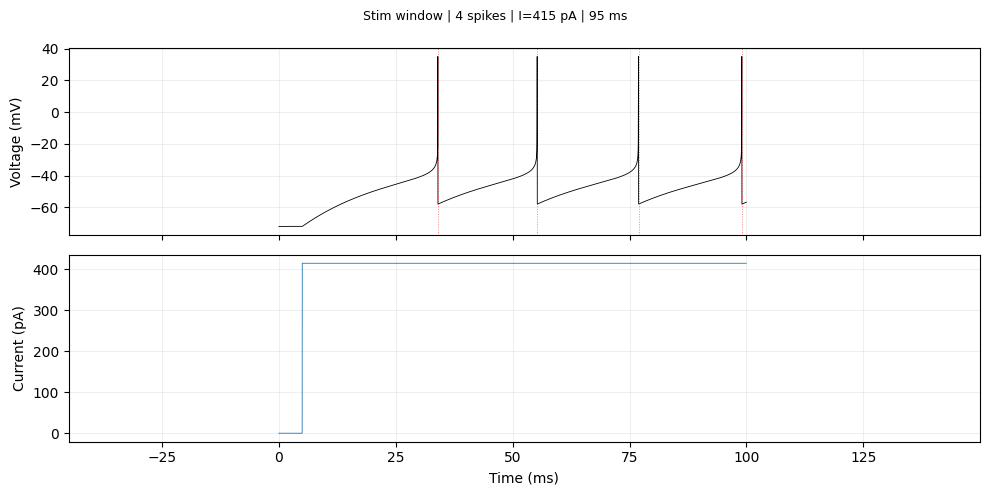

In [4]:
# --- Simulate ground truth ---
# IMPORTANT: use_surrogate=True so the forward pass matches the training cell exactly.
# AdEx uses jax.lax.select (boolean), AdExSurrogate uses arithmetic blend (s*a + (1-s)*b).
# Even though both produce 0/1 spikes, floating-point differences accumulate over 4000
# timesteps and cause a significant loss floor if mismatched.
sim_gt = simulate_with_current_trace(
    params=ground_truth_params,
    current_trace_pA=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    use_surrogate=True,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
)

print(f"Ground truth simulation: {sim_gt.n_spikes} spikes, {sim_gt.firing_rate_hz:.1f} Hz")

# --- Package as TraceData (same structure as experimental data) ---
# Jaxley may return one extra timestep; truncate to match the input current length
n = len(exp_cropped.time)
voltage_gt = sim_gt.voltage[:n].copy()

# Use spike times from the simulation's internal spike trace, NOT from detect_spikes().
# Jaxley resets voltage within the same timestep, so the recorded voltage never crosses
# the detection threshold — but the spike indicator is set correctly.
spike_times = sim_gt.spike_times

# Inject spike peaks into the voltage trace at known spike times.
# Jaxley's same-timestep reset means recorded voltage never shows the spike peak.
# Real experimental recordings show full peaks, so we restore them to make the
# synthetic data look like experimental data for feature extraction.
#
# IMPORTANT: This value must match the spike_peak_mv used in loss functions
# (e.g. MSELossConfig) to avoid an artificial loss floor from peak amplitude mismatch.
SPIKE_PEAK_MV = 35.0
for st in spike_times:
    idx = int(st / exp_cropped.dt_ms)
    if 0 <= idx < len(voltage_gt):
        voltage_gt[idx] = SPIKE_PEAK_MV

data = TraceData(
    time=exp_cropped.time,
    voltage=voltage_gt,
    current=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    spike_times=spike_times,
    stim_start_idx=exp_cropped.stim_start_idx,
    stim_end_idx=exp_cropped.stim_end_idx,
    stim_current_pA=exp_cropped.stim_current_pA,
)

print(f"\nSynthetic TraceData: {data.n_samples} samples, {data.n_spikes} spikes")
print(f"Spike times: {data.spike_times.round(1)} ms")
print(f"Stim window: idx {data.stim_start_idx} - {data.stim_end_idx} ({data.stim_duration_ms:.1f} ms)")

trace_stim_window_plot(data);

## 3. Perturbed Initial Parameters

Create initial parameters by adding ~15% noise to the ground truth.
This simulates the real scenario where we don't know the true values.

In [5]:
PERTURBATION = 0.15 # relative perturbation

# C_m, g_L, E_L, v_T, delta_T, v_reset, v_threshold, tau_w, a, b
# TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T", "tau_w", "a", "b"]

# Good:
# TRAINABLE_STAGE1 = ["C_m"] # good with lr 0.05
# TRAINABLE_STAGE1 = ["g_L"] # good with learning rate 0.05 and only that
# TRAINABLE_STAGE1 = ["v_reset"] # good with lr 0.05
# TRAINABLE_STAGE1 = ["v_T"] # good with learning rate 0.05 and 0.1
# TRAINABLE_STAGE1 = ["E_L"] # somewhat with lr 0.05
# TRAINABLE_STAGE1 = ["delta_T"] # good with lr 0.05

TRAINABLE_STAGE1 = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T"] # works somewhat well-ish, depending on perturbation

# Bad:
# TRAINABLE_STAGE1 = ["tau_w"] # no gradient information, in isolation doesn't do anything
# TRAINABLE_STAGE1 = ["a"] # no gradient information
# TRAINABLE_STAGE1 = ["b"] # no gradient information

def perturb_params(
    params: dict,
    trainable: list[str],
    perturbation: float,
    key: jax.Array,
) -> dict:
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        # Scale noise by parameter range to handle params near zero (e.g. a=0)
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


all_trainable = list(set(TRAINABLE_STAGE1))
initial_params = perturb_params(
    ground_truth_params, all_trainable, PERTURBATION, jr.PRNGKey(SEED)
)
# initial_params["C_m"] = initial_params["C_m"] + 10
# initial_params["v_reset"] = initial_params["v_reset"] - 10

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
v_T               -45.000      -44.773     0.9%
g_L                10.000       10.546     6.8%
delta_T             3.000        3.953     5.0%
E_L               -72.000      -73.498     3.3%
C_m               200.000      216.818     7.3%
v_reset           -58.000      -58.900     2.6%


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Initial simulation: 2 spikes (target: 4)
Gamma = -0.123


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


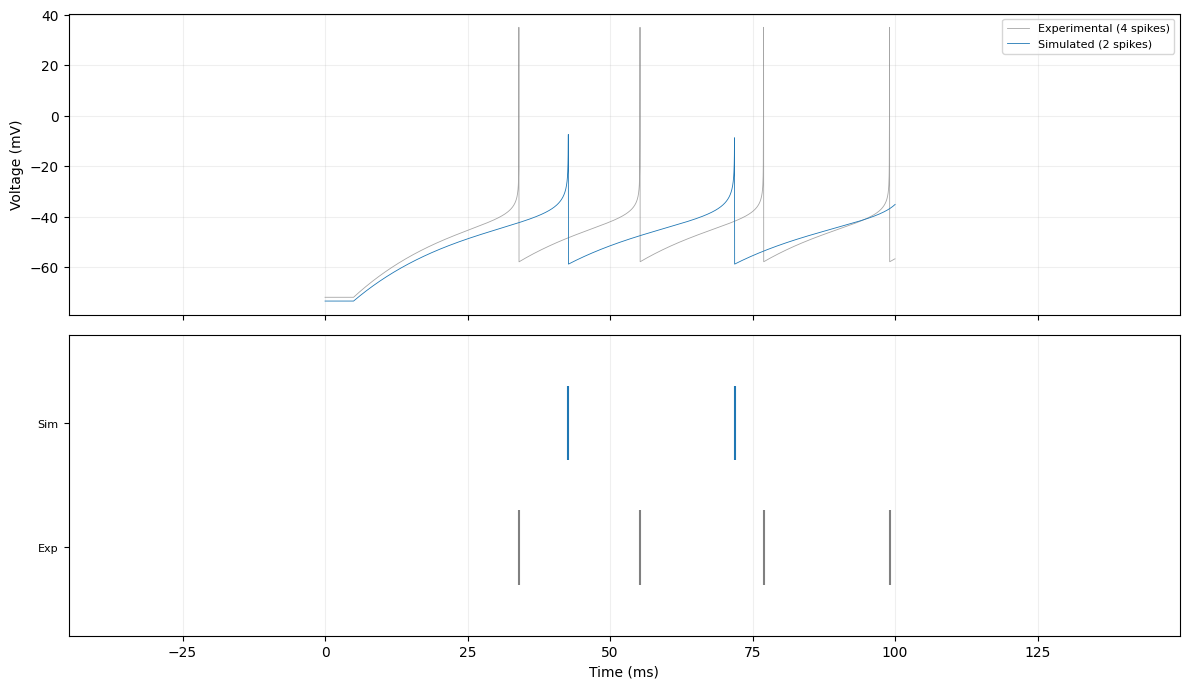

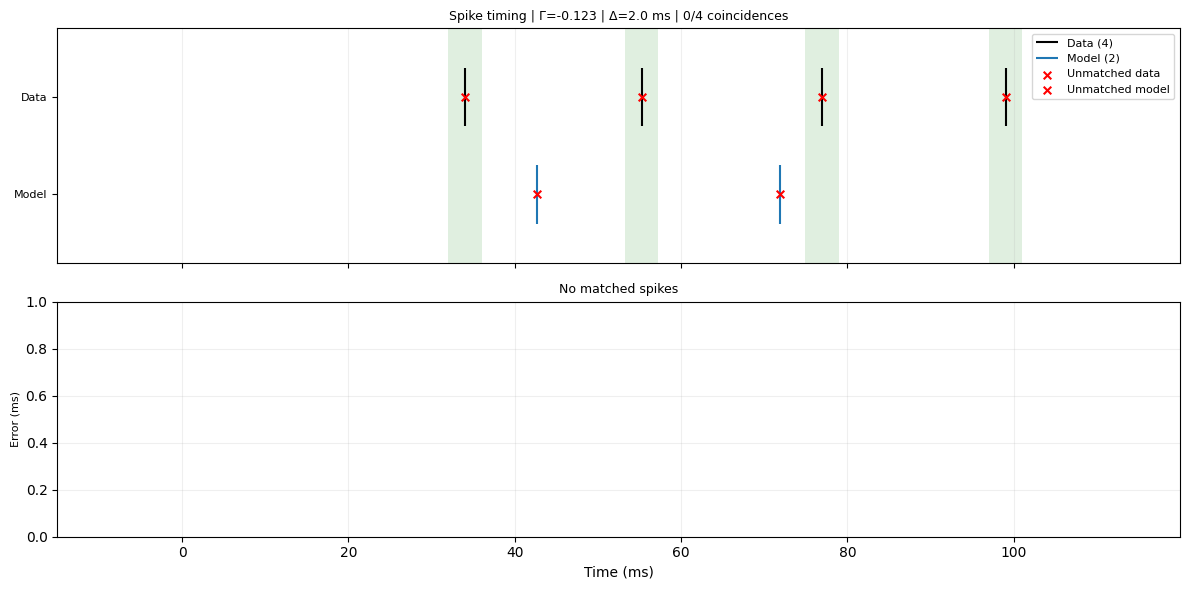

In [6]:
# Simulate with perturbed initial parameters to see the starting point
sim_init = simulate_with_current_trace(
    params=initial_params,
    # params=ground_truth_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")


if sim_init.n_spikes > 0 and data.n_spikes > 0:
    cf_s0 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_init.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s0.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_init);

if cf_s0 is not None:
    spike_timing_plot(data, sim_init, cf_s0);


In [7]:
# --- Establish loss floors: evaluate losses at ground truth parameters ---
# The soft feature extraction (used during training) won't exactly match the hard
# feature extraction (used for targets), creating an irreducible baseline loss.

# -- Stage 1 floor (Guarino) --
_config_gt = TrainingConfig(
    surrogate_type="superspike", surrogate_slope=2.0, clip_to_bounds=True,
)
_cell_gt1, _stim_gt1, _tmax_gt1, _params_gt1 = setup_trainable_cell(
    initial_params=ground_truth_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    config=_config_gt,
    trainable_params=TRAINABLE_STAGE1,
)
_exp_features = extract_experimental_features(
    voltage_trace=data.voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)
_loss_fn_gt1 = make_guarino_loss_fn(
    cell=_cell_gt1, data_stimuli=_stim_gt1, t_max=_tmax_gt1, dt_ms=data.dt_ms,
    exp_features=_exp_features, stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    loss_config=GuarinoLossConfig(),
)
loss_floor_s1 = float(_loss_fn_gt1(_params_gt1))

print(f"Loss floor (Guarino  at ground truth): {loss_floor_s1:.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Loss floor (Guarino  at ground truth): 0.0025


## 4. Stage 1 — Guarino Loss (Coarse Feature Matching)

In [8]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
exp_voltage = jnp.array(data.voltage)

# --- Stage 1 config ---
config_stage1 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.05,
    n_epochs=200,
    surrogate_type="sigmoid",
    surrogate_slope=2,
    print_every=10,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    # initial_params=ground_truth_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    config=config_stage1,
    trainable_params=TRAINABLE_STAGE1,
)

# Extract target features for Guarino loss
exp_features = extract_experimental_features(
    voltage_trace=exp_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)

loss_fn_stage1 = make_guarino_loss_fn(
    cell=cell1,
    data_stimuli=data_stimuli1,
    t_max=t_max1,
    dt_ms=data.dt_ms,
    exp_features=exp_features,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
    #loss_config=GuarinoLossConfig(
    #    weight_t_first=1.0,
    #    weight_t_second=2.0,
    #    weight_t_third=3.0,
    #    weight_t_last=4.0,
    #    weight_firing_freq=1.0,
    #    weight_spike_count=0.1,
    #),
    loss_config=GuarinoLossConfig(),
)

print(f"Initial Guarino loss: {float(loss_fn_stage1(trainable_params1)):.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Initial Guarino loss: 5.2247


In [9]:
result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=config_stage1,
    initial_params=initial_params,
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Training: optimizer=polyak lr=0.05 epochs=200 surrogate=sigmoid slope=2.0 alpha=1.0 beta=0.85 sigmoid_transform
Epoch    0 | loss=5.224713 | grad_norm=6.90e-01 | lr=2.61e-01 | C_m=217.4504, g_L=10.7067, v_reset=-59.6677, v_T=-43.8869, E_L=-74.5675, delta_T=3.9225
Epoch   10 | loss=1.350871 | grad_norm=1.30e-01 | lr=6.75e-02 | C_m=213.7525, g_L=9.9928, v_reset=-59.9925, v_T=-48.9770, E_L=-70.0075, delta_T=3.5674
Epoch   20 | loss=0.071581 | grad_norm=1.44e-01 | lr=3.58e-03 | C_m=216.3412, g_L=10.1290, v_reset=-60.3264, v_T=-46.9150, E_L=-70.8329, delta_T=3.8093
Epoch   30 | loss=0.145876 | grad_norm=9.59e+01 | lr=7.29e-03 | C_m=216.1831, g_L=10.1110, v_reset=-59.9622, v_T=-47.1347, E_L=-70.7500, delta_T=3.7868
Epoch   40 | loss=0.055699 | grad_norm=1.41e-01 | lr=2.78e-03 | C_m=216.4042, g_L=10.1333, v_reset=-60.0648, v_T=-46.8533, E_L=-70.8607, delta_T=3.8165
Epoch   50 | loss=1.305359 | grad_norm=2.09e+05 | lr=6.53e-02 | C_m=216.3943, g_L=9.9164, v_reset=-62.4589, v_T=-47.3258, E_L=-69


Stage 1 complete.
  Best loss:   0.0554
  Total time:  1.1 s


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 1: 4 spikes (target: 4)
Gamma = 1.000


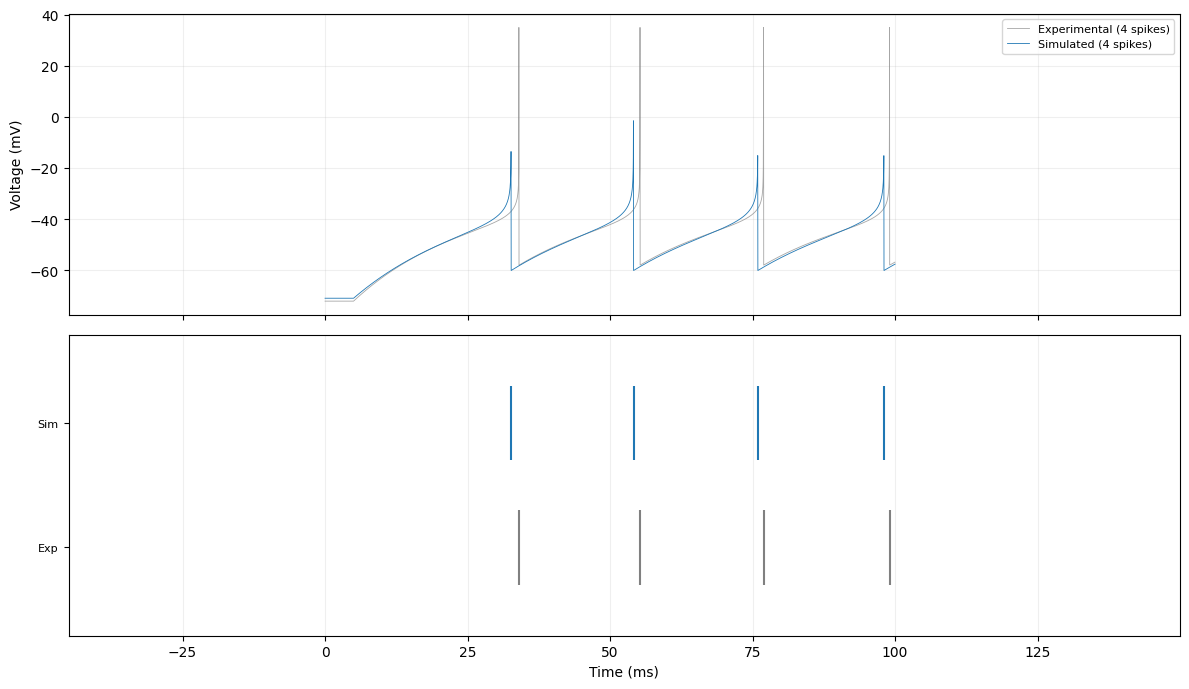

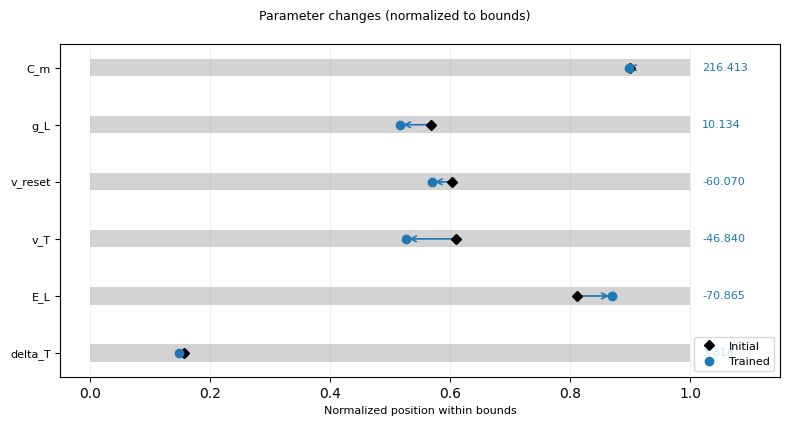

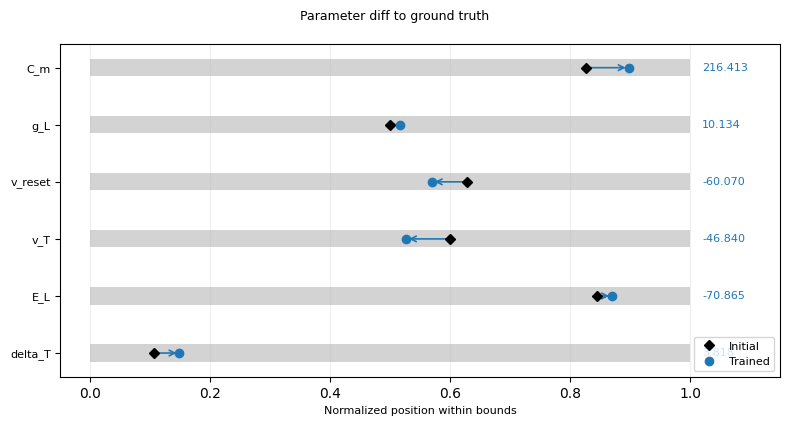

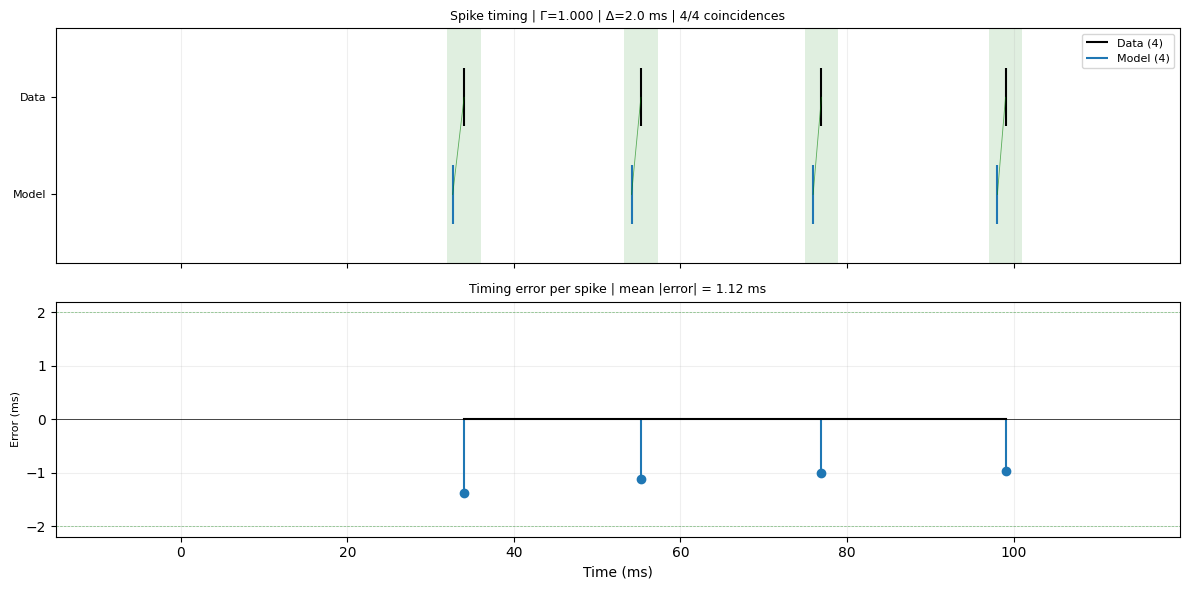

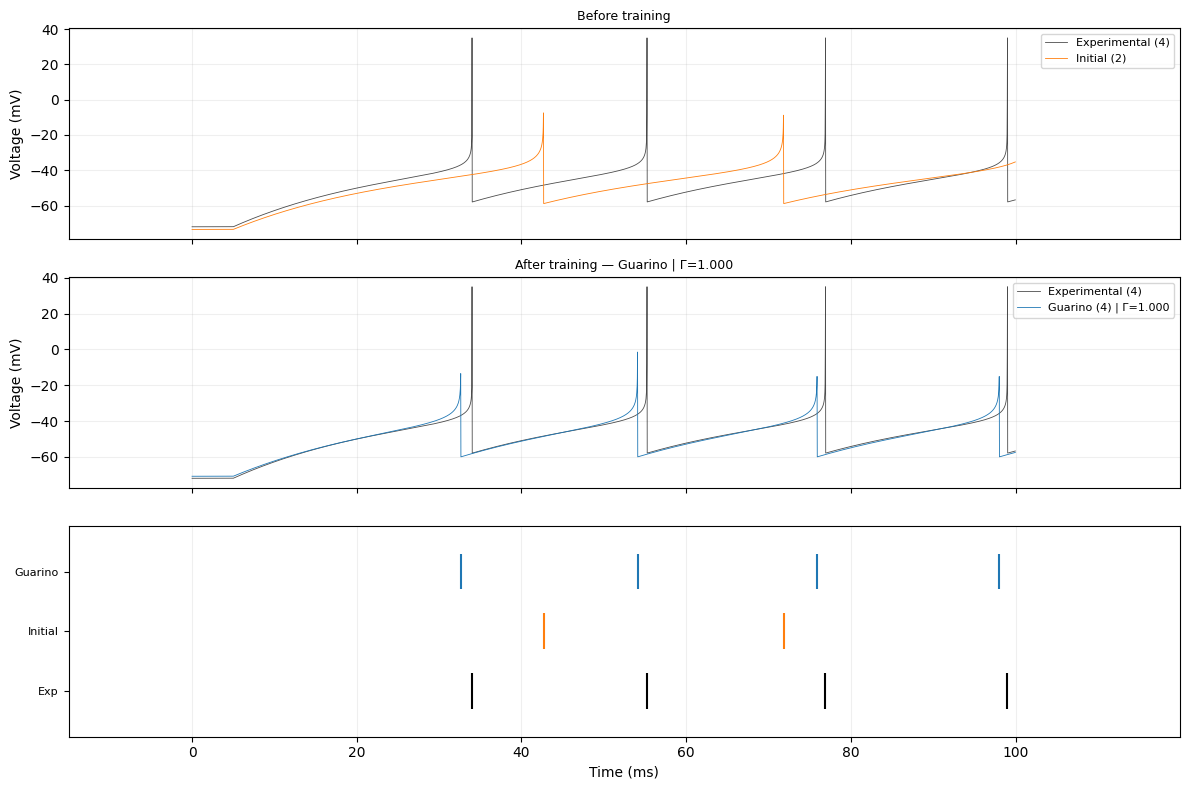

In [10]:
# Evaluate stage 1
params_after_s1 = dict(initial_params)
params_after_s1.update(result_stage1.get_params_dict())

sim_stage1 = simulate_with_current_trace(
    params=params_after_s1,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1);
parameter_comparison_plot(TrainingResult(
    trainable_params=result_stage1.trainable_params,
    loss_history=result_stage1.loss_history,
    time_per_epoch=result_stage1.time_per_epoch,
    config=result_stage1.config,
    initial_params=ground_truth_params), figtitle="Parameter diff to ground truth");

if cf_s1 is not None:
    spike_timing_plot(data, sim_stage1, cf_s1);


fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1],
    coincidence=[cf_s1],
    labels=["Guarino"],
);